# **Preprocessing & Feature Engineering**

## Introduction

Objective of this notebook:

- Load cleaned dataset

- Create multiclass target

- Engineer new features

- Build binary and multiclass datasets

- Split data

- Apply preprocessing pipeline

- Validate no leakage

- Save final artifacts


This notebook produces:

```text
data/processed/
│
├── binary_full_dataset.csv
├── multiclass_full_dataset.csv
├── binary_dataset.pkl
├── multiclass_dataset.pkl
├── preprocessor.pkl

```

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from preprocessing import (
    create_multiclass_target,
    drop_failure_columns,
    build_binary_dataset,
    build_multiclass_dataset,
    split_data,
    build_preprocessing_pipeline
)

from feature_engineering import create_engineered_features

## Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/interim/cleaned_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 12)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


At this stage:

- ID & UDI removed

- Raw failure columns still exist

- No engineered features yet

## Create Multiclass Target

In [3]:
df = create_multiclass_target(df)

df["Failure Type"].value_counts()

Failure Type
No Failure          9652
HDF                  106
PWF                   80
OSF                   78
TWF                   42
Multiple Failure      24
RNF                   18
Name: count, dtype: int64

### Visualize Class Distribution

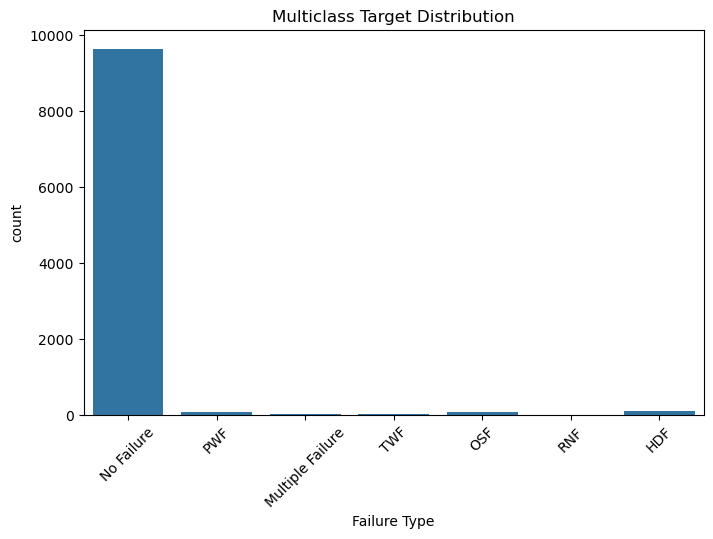

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Failure Type")
plt.xticks(rotation=45)
plt.title("Multiclass Target Distribution")
plt.show()

- Observe strong class imbalance

- Majority class likely “No Failure”

- Important for later model handling

## Drop Individual Failure Columns (Leakage Prevention)

In [5]:
df = drop_failure_columns(df)

print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Failure Type'],
      dtype='object')


If we leave:

PWF, OSF, TWF, HDF, RNF

The model would directly see failure indicators.

That would be data leakage.

## Feature Engineering

In [6]:
df = create_engineered_features(df)

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Failure Type,Temp_diff,Power
0,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,56320.0


Engineered Features Typically Include:

- Temperature difference

- Power (Torque × Rotational speed)


Engineered features help the model learn:

- Mechanical stress

- Thermal instability

- Energy load

## Save Full Ready Datasets (No Split)

These are reusable research datasets.

In [7]:
df_full = df.copy()

binary_full = df_full.drop(columns=["Failure Type"])
multiclass_full = df_full.drop(columns=["Machine failure"])

os.makedirs("../data/processed", exist_ok=True)

binary_full.to_csv("../data/processed/binary_full_dataset.csv", index=False)
multiclass_full.to_csv("../data/processed/multiclass_full_dataset.csv", index=False)

print("Full datasets saved.")

Full datasets saved.


## Build Modeling Datasets

In [8]:
X_binary, y_binary = build_binary_dataset(df)
X_multi, y_multi = build_multiclass_dataset(df)

print("Binary shape:", X_binary.shape)
print("Multiclass shape:", X_multi.shape)

Binary shape: (10000, 8)
Multiclass shape: (10000, 8)


## Train/Test Split

In [9]:
Xb_train, Xb_test, yb_train, yb_test = split_data(X_binary, y_binary)
Xm_train, Xm_test, ym_train, ym_test = split_data(X_multi, y_multi)

print("Binary Train:", Xb_train.shape)
print("Binary Test:", Xb_test.shape)

Binary Train: (7000, 8)
Binary Test: (3000, 8)


## Validate Split Ratio

In [10]:
print("Train ratio:", len(yb_train)/len(y_binary))
print("Test ratio:", len(yb_test)/len(y_binary))

Train ratio: 0.7
Test ratio: 0.3


## Check Target Balance After Split

In [11]:
print("Binary Train Distribution:")
print(yb_train.value_counts(normalize=True))

print("\nBinary Test Distribution:")
print(yb_test.value_counts(normalize=True))

Binary Train Distribution:
Machine failure
0    0.966143
1    0.033857
Name: proportion, dtype: float64

Binary Test Distribution:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [12]:
print("Multi Train Distribution:")
print(ym_train.value_counts(normalize=True))

print("\nMulti Test Distribution:")
print(ym_test.value_counts(normalize=True))

Multi Train Distribution:
Failure Type
No Failure          0.965143
HDF                 0.010571
PWF                 0.008000
OSF                 0.007857
TWF                 0.004143
Multiple Failure    0.002429
RNF                 0.001857
Name: proportion, dtype: float64

Multi Test Distribution:
Failure Type
No Failure          0.965333
HDF                 0.010667
PWF                 0.008000
OSF                 0.007667
TWF                 0.004333
Multiple Failure    0.002333
RNF                 0.001667
Name: proportion, dtype: float64


**This confirms stratification worked.**

## Build Preprocessing Pipeline

In [13]:
preprocessor = build_preprocessing_pipeline(Xb_train)

## Apply Transformations

In [14]:
Xb_train_p = preprocessor.fit_transform(Xb_train)
Xb_test_p = preprocessor.transform(Xb_test)

Xm_train_p = preprocessor.transform(Xm_train)
Xm_test_p = preprocessor.transform(Xm_test)

## Feature Count After Encoding

In [15]:
feature_names = preprocessor.get_feature_names_out()

print("Total encoded features:", len(feature_names))

Total encoded features: 10


## Leakage Check

In [16]:
for col in feature_names:
    if any(failure in col for failure in ["TWF", "HDF", "PWF", "OSF", "RNF"]):
        print("Leakage detected:", col)

## Visualize Feature Space Size

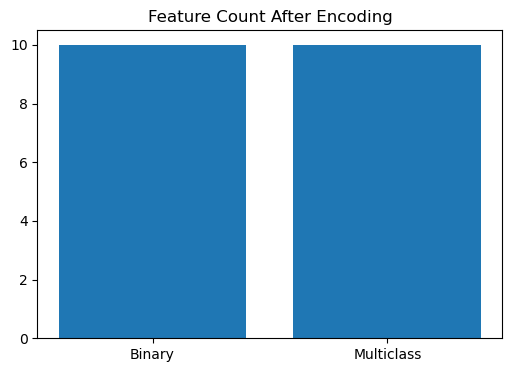

In [17]:
plt.figure(figsize=(6,4))
plt.bar(["Binary","Multiclass"],
        [Xb_train_p.shape[1], Xm_train_p.shape[1]])
plt.title("Feature Count After Encoding")
plt.show()

# **Imbalance Handling**

In [18]:
from imblearn.combine import SMOTEENN

## Apply SMOTEENN to Binary Training Set

In [19]:
# Apply SMOTEENN to Binary Training Data
smote_enn_binary = SMOTEENN(random_state=42)

Xb_train_bal, yb_train_bal = smote_enn_binary.fit_resample(
    Xb_train_p,
    yb_train
)

print("Before SMOTEENN (Binary):")
print(yb_train.value_counts())

print("\nAfter SMOTEENN (Binary):")
print(pd.Series(yb_train_bal).value_counts())

Before SMOTEENN (Binary):
Machine failure
0    6763
1     237
Name: count, dtype: int64

After SMOTEENN (Binary):
Machine failure
1    5727
0    5225
Name: count, dtype: int64


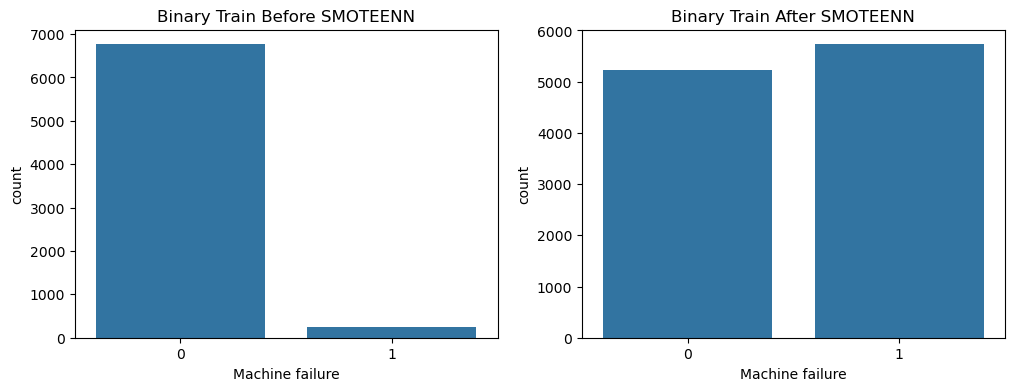

In [20]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(x=yb_train, ax=axes[0])
axes[0].set_title("Binary Train Before SMOTEENN")

sns.countplot(x=yb_train_bal, ax=axes[1])
axes[1].set_title("Binary Train After SMOTEENN")

plt.show()

## Apply SMOTEENN to Multiclass Training Set

In [21]:
# Apply SMOTEENN to Multiclass Training Data
smote_enn_multi = SMOTEENN(random_state=42)

Xm_train_bal, ym_train_bal = smote_enn_multi.fit_resample(
    Xm_train_p,
    ym_train
)

print("Before SMOTEENN (Multiclass):")
print(ym_train.value_counts())

print("\nAfter SMOTEENN (Multiclass):")
print(pd.Series(ym_train_bal).value_counts())

Before SMOTEENN (Multiclass):
Failure Type
No Failure          6756
HDF                   74
PWF                   56
OSF                   55
TWF                   29
Multiple Failure      17
RNF                   13
Name: count, dtype: int64

After SMOTEENN (Multiclass):
Failure Type
PWF                 6611
HDF                 6203
OSF                 6175
TWF                 5982
Multiple Failure    5619
RNF                 4991
No Failure          3285
Name: count, dtype: int64


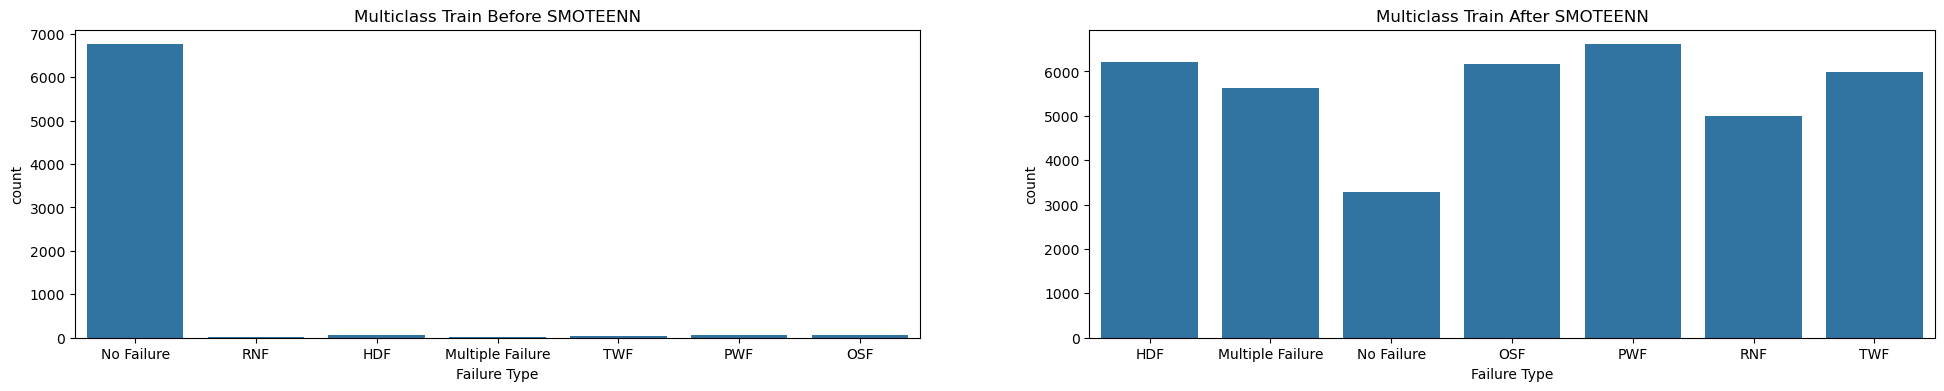

In [22]:
fig, axes = plt.subplots(1,2, figsize=(24,4))

sns.countplot(x=ym_train, ax=axes[0])
axes[0].set_title("Multiclass Train Before SMOTEENN")

sns.countplot(x=ym_train_bal, ax=axes[1])
axes[1].set_title("Multiclass Train After SMOTEENN")

plt.show()

## Final Clean Saving Artifacts

In [23]:
# Save Preprocessor
joblib.dump(preprocessor, "../data/processed/preprocessor.pkl")

# Save Binary Dataset (Balanced Train + Original Test)
pd.to_pickle(
    (Xb_train_bal, Xb_test_p, yb_train_bal, yb_test),
    "../data/processed/binary_dataset.pkl"
)

# Save Multiclass Dataset (Balanced Train + Original Test)
pd.to_pickle(
    (Xm_train_bal, Xm_test_p, ym_train_bal, ym_test),
    "../data/processed/multiclass_dataset.pkl"
)

print("Processed datasets with SMOTEENN saved successfully.")

Processed datasets with SMOTEENN saved successfully.


# Final Dataset Summary

| Dataset                       | Purpose                                   | Notes                                            |
| ----------------------------- | ----------------------------------------- | ------------------------------------------------ |
| `binary_full_dataset.csv`     | Full cleaned dataset (binary target)      | No split, no scaling, no balancing               |
| `multiclass_full_dataset.csv` | Full cleaned dataset (multiclass target)  | No split, no scaling, no balancing               |
| `binary_dataset.pkl`          | Processed train/test dataset (binary)     | **Train balanced with SMOTEENN**, test untouched |
| `multiclass_dataset.pkl`      | Processed train/test dataset (multiclass) | **Train balanced with SMOTEENN**, test untouched |
| `preprocessor.pkl`            | Saved preprocessing pipeline              | Used for scaling & encoding future data          |



🔹 binary_dataset.pkl
```text
(
  Xb_train_bal,   ← SMOTEENN balanced
  Xb_test_p,      ← original distribution
  yb_train_bal,   ← SMOTEENN balanced
  yb_test         ← original distribution
)
```

🔹 multiclass_dataset.pkl
```text
(
  Xm_train_bal,   ← SMOTEENN balanced
  Xm_test_p,      ← original distribution
  ym_train_bal,   ← SMOTEENN balanced
  ym_test         ← original distribution
)
```

**`Important Design Principle`**

```text
• Balancing is applied ONLY to training data.
• Test data remains untouched to reflect real-world failure distribution.
• This ensures fair and realistic model evaluation.
```


---

**`Next Notebook →  03_model_training.ipynb`**, we will train and evaluate machine learning models using the SMOTEENN-balanced training data while assessing performance on the untouched real-world test set.